In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

# Ignore warnings to keep the notebook output clean
warnings.filterwarnings('ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Set up plot styles
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
sns.set_theme(style="whitegrid")

# Create a folder to save plots for the presentation
FIG_DIR = "./figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_plot(filename):
    plt.savefig(os.path.join(FIG_DIR, filename), bbox_inches='tight')

# Import my custom script to help find the best model
import sys
sys.path.append('./ml_utils')
from mesh_utils_optimized import find_best_model

In [2]:
print("Loading dataset...")
df = pd.read_csv("movie_metadata.csv")

# Drop rows where the target variable is missing
df = df.dropna(subset=['imdb_score'])

# Drop the movie link column since we do not need it
if 'movie_imdb_link' in df.columns:
    df = df.drop(columns=['movie_imdb_link'])

Loading dataset...


In [3]:
print("Filling in missing data...")
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numericals with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categoricals with 'Unknown' or mode
for col in cat_cols:
    if col in ['director_name', 'actor_1_name', 'actor_2_name', 'actor_3_name', 'plot_keywords']:
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Create the target variable to classify movies as Flop, Average, or Hit")
bins = [0, 3, 6, 10]
labels = ['Flop', 'Average', 'Hit']
df['Classify'] = pd.cut(df['imdb_score'], bins=bins, labels=labels, include_lowest=True)

# Drop the original imdb_score column so the model does not cheat and know the answer
df = df.drop(columns=['imdb_score'])

Filling in missing data...
Create the target variable to classify movies as Flop, Average, or Hit


Look at feature relationships and outliers


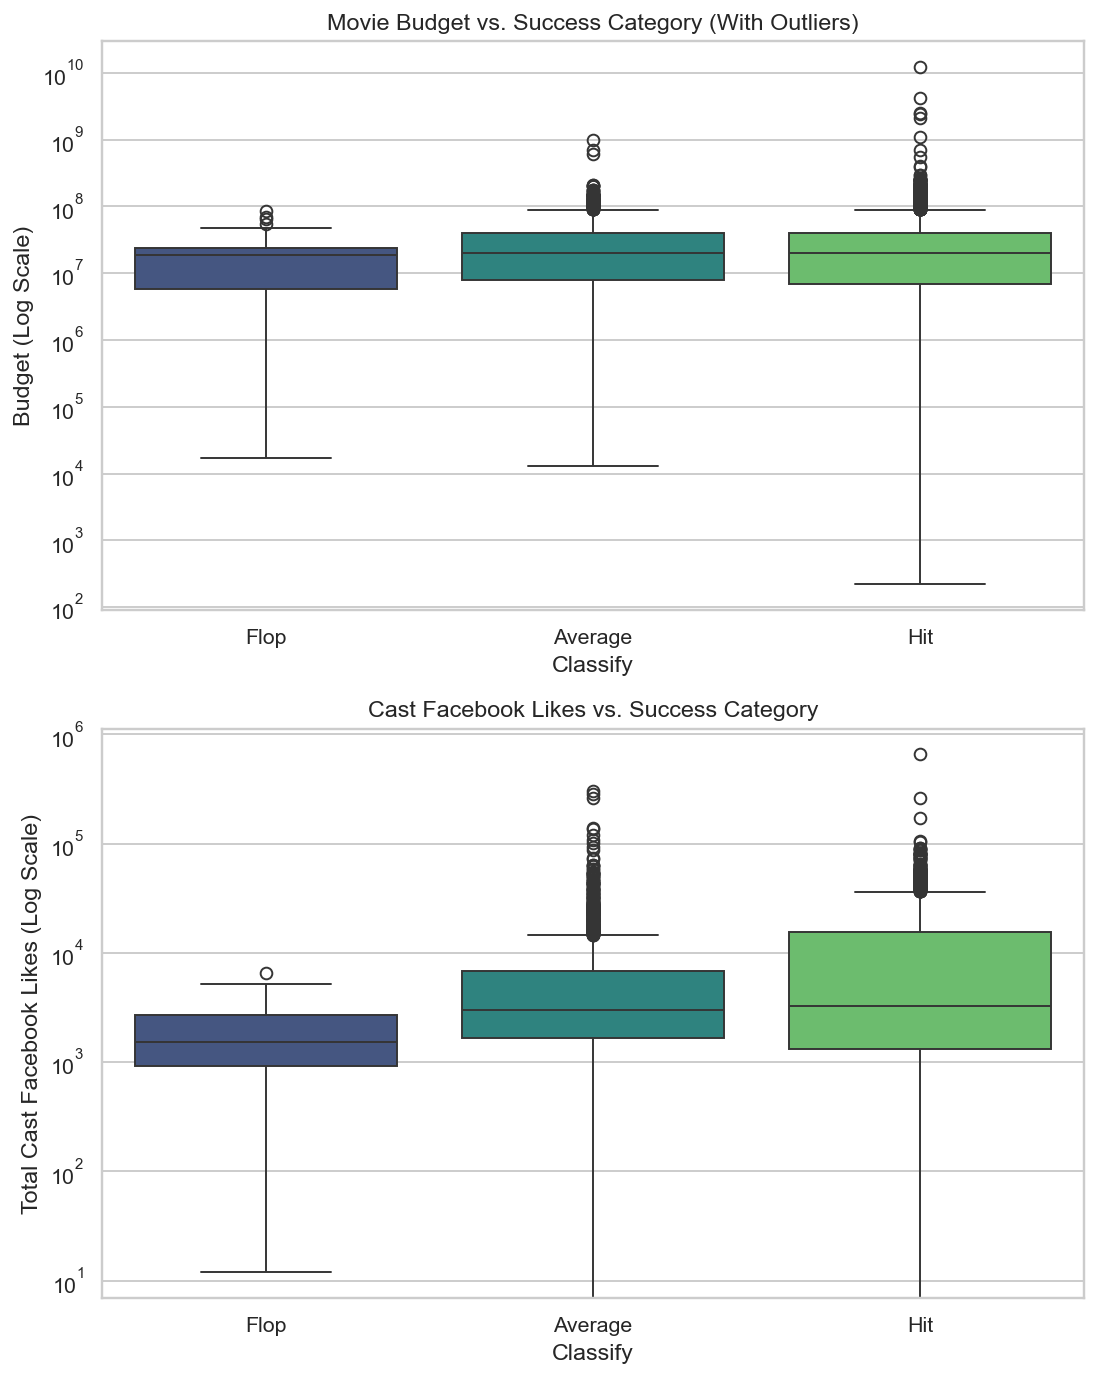

In [4]:

print("Look at feature relationships and outliers")

required_cols = ['budget', 'cast_total_facebook_likes', 'Classify']
if all(col in df.columns for col in required_cols):
    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    sns.boxplot(data=df, x='Classify', y='budget', hue='Classify', order=['Flop', 'Average', 'Hit'], palette='viridis', legend=False, ax=axes[0])
    axes[0].set_title('Movie Budget vs. Success Category (With Outliers)')
    axes[0].set_yscale('log')
    axes[0].set_ylabel('Budget (Log Scale)')

    sns.boxplot(data=df, x='Classify', y='cast_total_facebook_likes', hue='Classify', order=['Flop', 'Average', 'Hit'], palette='viridis', legend=False, ax=axes[1])
    axes[1].set_title('Cast Facebook Likes vs. Success Category')
    axes[1].set_yscale('log')
    axes[1].set_ylabel('Total Cast Facebook Likes (Log Scale)')

    plt.tight_layout()
    save_plot('eda_outliers_relationships.png')
    plt.show()
else:
    missing_cols = [col for col in required_cols if col not in df.columns]
    print(f"Skipped outlier boxplots; missing columns: {missing_cols}")

Exploratory Data Analysis (EDA)
Target Variable Distribution


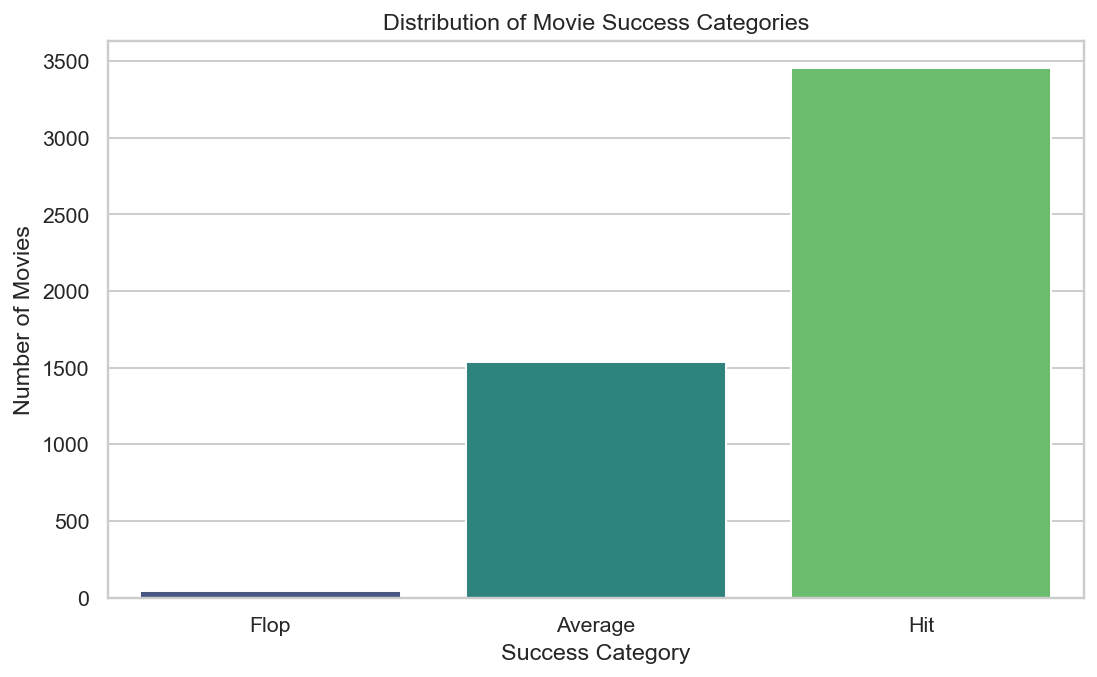

Notice the data is imbalanced, so F1-score will be a better metric than accuracy.


In [5]:
print("Exploratory Data Analysis (EDA)")
print("Target Variable Distribution")
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Classify', hue='Classify', order=['Flop', 'Average', 'Hit'], palette='viridis', legend=False)
plt.title('Distribution of Movie Success Categories')
plt.ylabel('Number of Movies')
plt.xlabel('Success Category')
plt.tight_layout()
save_plot('eda_target_distribution.png')
plt.show()
print("Notice the data is imbalanced, so F1-score will be a better metric than accuracy.")

Generating Bivariate EDA Visualizations...


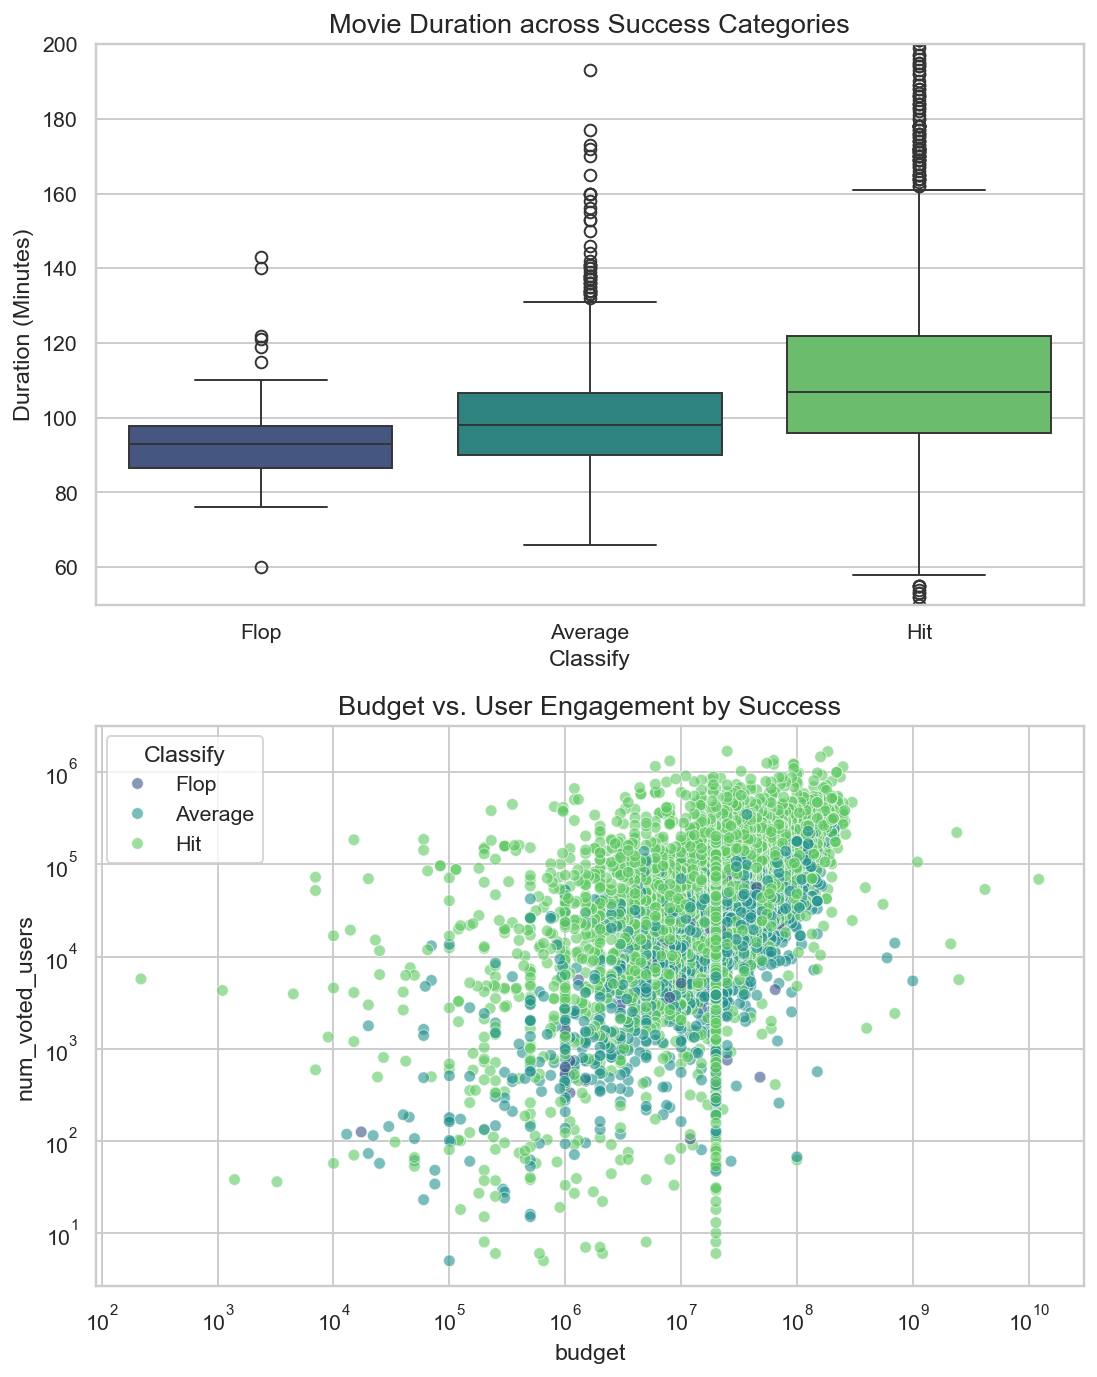

In [6]:

print("Generating Bivariate EDA Visualizations...")
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Plot 1: Duration vs. Success
sns.boxplot(x='Classify', y='duration', hue='Classify', data=df, palette='viridis', order=['Flop', 'Average', 'Hit'], legend=False, ax=axes[0])
axes[0].set_title('Movie Duration across Success Categories', fontsize=14)
axes[0].set_ylabel('Duration (Minutes)')
axes[0].set_ylim(50, 200) # Capping outliers for a cleaner visual

# Plot 2: Budget vs User Engagement Scatter
# Using num_voted_users as an engagement metric
sns.scatterplot(x='budget', y='num_voted_users', hue='Classify', data=df, palette='viridis', alpha=0.6, ax=axes[1])
axes[1].set_title('Budget vs. User Engagement by Success', fontsize=14)
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
save_plot('bivariate_analysis.png')
plt.show()

Generating Correlation Heatmap...


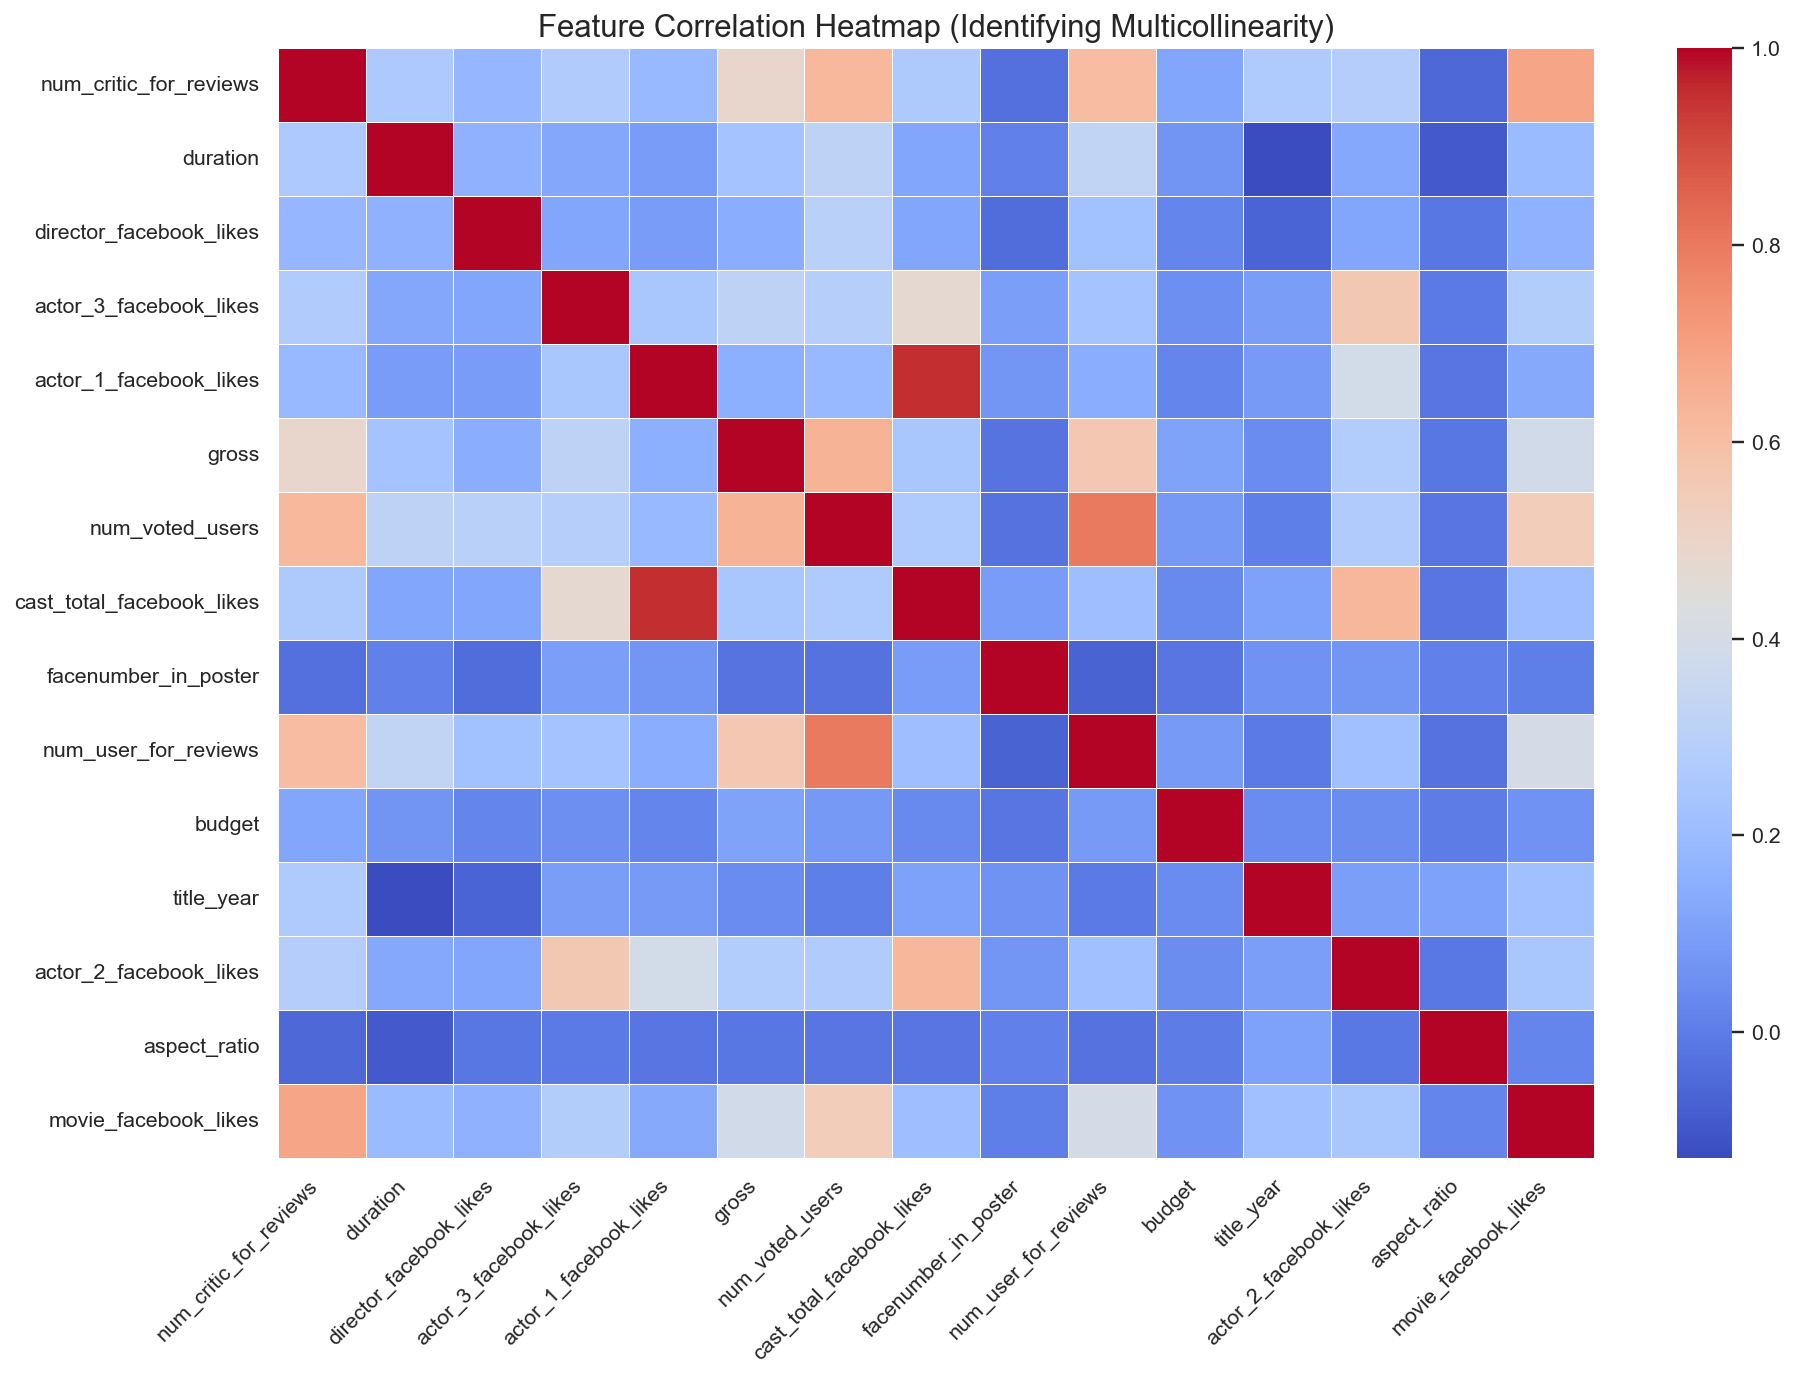

Slide Value: Use this to visually justify why you dropped redundant columns.


In [7]:

print("Generating Correlation Heatmap...")
plt.figure(figsize=(14, 10))
# Calculate correlation only on numeric columns
corr = df.select_dtypes(include=[np.number]).corr()

# Create a heatmap
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Feature Correlation Heatmap (Identifying Multicollinearity)', fontsize=16)
plt.tight_layout()
save_plot('correlation_heatmap.png')
plt.show()
print("Slide Value: Use this to visually justify why you dropped redundant columns.")

In [8]:
print("Find and drop features that are too highly correlated")
num_features = df.select_dtypes(include=[np.number])
corr_matrix = num_features.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.80)]

print(f"Dropping highly correlated columns: {to_drop}")
df = df.drop(columns=to_drop)

# Separate Features (X) and Target (y)
X = df.drop(columns=['Classify'])
y = df['Classify']

Find and drop features that are too highly correlated
Dropping highly correlated columns: ['cast_total_facebook_likes']


In [9]:
print("Splitting data into Train and Test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Splitting data into Train and Test sets...
Training set shape: (4034, 25)
Testing set shape: (1009, 25)


In [10]:
print("Encode categorical variables and scale numerical ones")

# Identify categorical and numerical columns in the updated X
cat_cols_X = X_train.select_dtypes(include=['object', 'category']).columns
num_cols_X = X_train.select_dtypes(include=[np.number]).columns

# Use OrdinalEncoder for text columns
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

if len(cat_cols_X) > 0:
    X_train_encoded[cat_cols_X] = encoder.fit_transform(X_train[cat_cols_X])
    X_test_encoded[cat_cols_X] = encoder.transform(X_test[cat_cols_X])

# 2. Scale Numericals
scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[num_cols_X] = scaler.fit_transform(X_train_encoded[num_cols_X])
X_test_scaled[num_cols_X] = scaler.transform(X_test_encoded[num_cols_X])

print("Finished encoding and scaling.")

Encode categorical variables and scale numerical ones
Finished encoding and scaling.


In [11]:
print("Use SMOTE to balance the classes")
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# Encode the target labels to numbers
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

print("Applying SMOTE so we have equal amounts of Flop, Average, and Hit rows in the training data")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_encoded)

print(f"Original training shape: {X_train_scaled.shape}")
print(f"Resampled training shape: {X_train_resampled.shape}")

Use SMOTE to balance the classes
Applying SMOTE so we have equal amounts of Flop, Average, and Hit rows in the training data
Original training shape: (4034, 25)
Resampled training shape: (8298, 25)


Visualizing SMOTE Impact on Training Data...


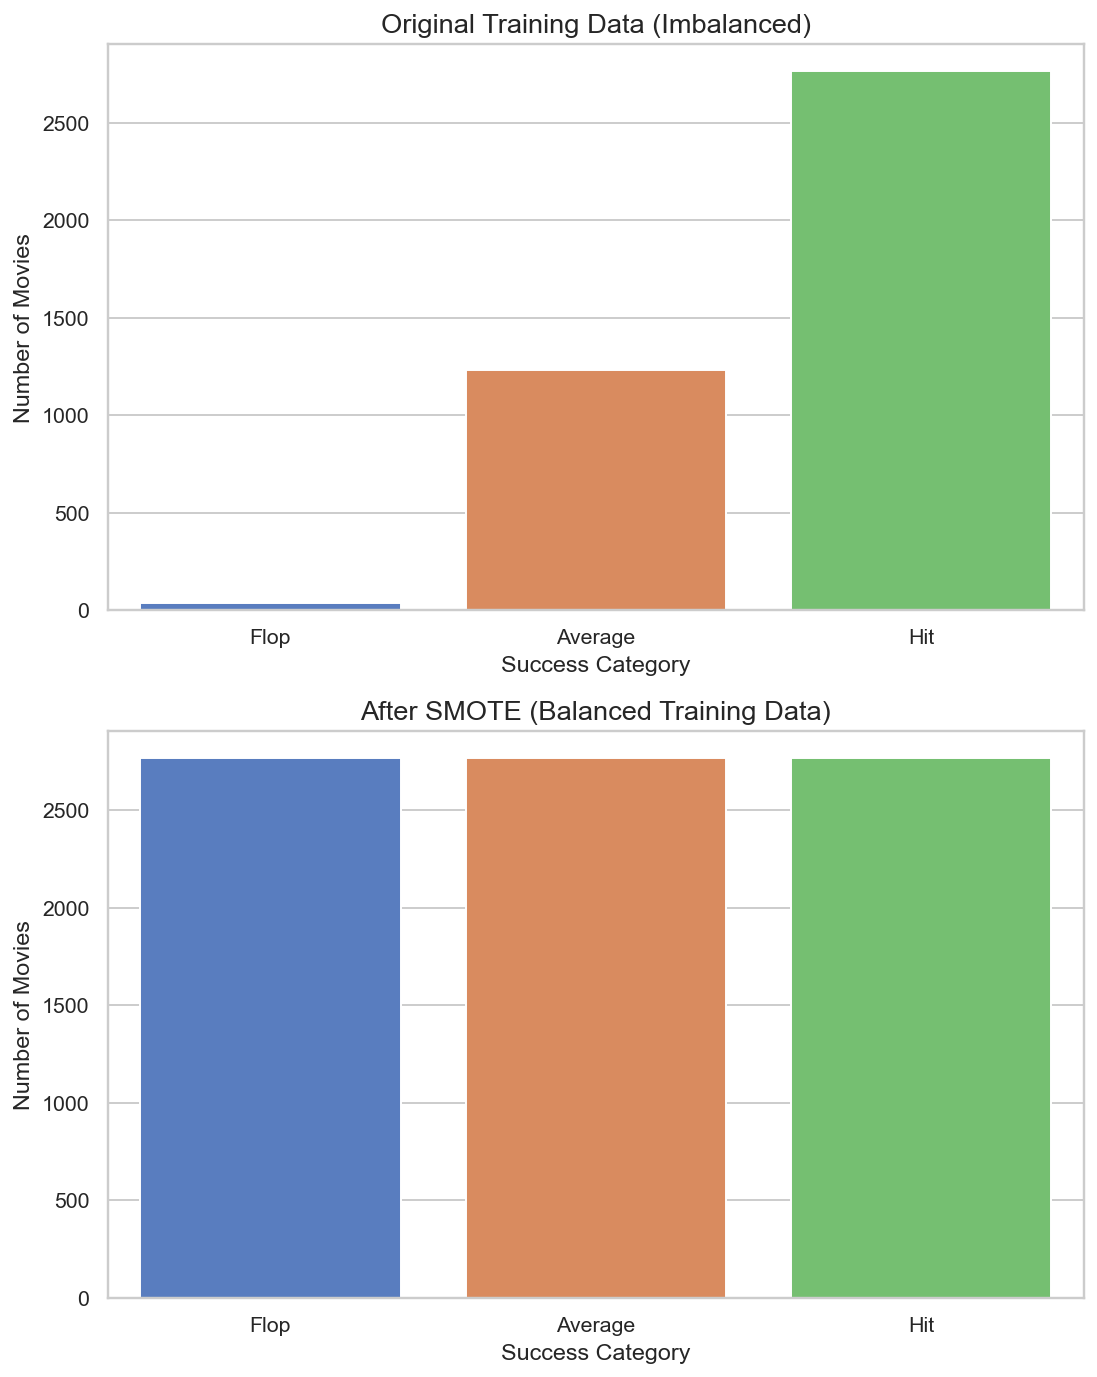

In [12]:

print("Visualizing SMOTE Impact on Training Data...")
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Before SMOTE
# y_train is the original pandas series
sns.countplot(x=y_train, order=['Flop', 'Average', 'Hit'], palette='muted', ax=axes[0])
axes[0].set_title('Original Training Data (Imbalanced)', fontsize=14)
axes[0].set_ylabel('Number of Movies')
axes[0].set_xlabel('Success Category')

# After SMOTE
# y_train_resampled is encoded, so we decode it for the plot
decoded_y_train_resampled = target_encoder.inverse_transform(y_train_resampled)
sns.countplot(x=decoded_y_train_resampled, order=['Flop', 'Average', 'Hit'], palette='muted', ax=axes[1])
axes[1].set_title('After SMOTE (Balanced Training Data)', fontsize=14)
axes[1].set_ylabel('Number of Movies')
axes[1].set_xlabel('Success Category')

plt.tight_layout()
save_plot('smote_balance_comparison.png')
plt.show()

In [13]:
print("\nRunning Model Selection")


print("Testing models using RandomizedSearchCV...")

# Run my custom search function to find the best model
best_model_results, all_models_results = find_best_model(
    x=X_train_resampled,
    y=y_train_resampled,
    problem_type='classification',
    metric='f1',  # maps to f1_weighted in util script
    n_iter=10,
    x_test=X_test_scaled,
    y_test=y_test_encoded,
    cv=5
)

print(f"\nBest Model Found: {best_model_results['best_model_name']}")
print(f"Optimal Parameters: {best_model_results['best_params']}")
print(f"Cross-Validation F1 Score: {best_model_results['CV_score']:.4f}")
print(f"Holdout Test F1 Score: {best_model_results['Test_score']:.4f}")

# Get the best model and make predictions
best_model = best_model_results['trained_model']
y_pred_encoded = best_model.predict(X_test_scaled)
y_pred = target_encoder.inverse_transform(y_pred_encoded)

print("\nClassification Report for Best Model")
print(classification_report(y_test, y_pred, zero_division=0))


Running Model Selection
Testing models using RandomizedSearchCV...
Training models for classification using f1 (RandomizedSearchCV)...

Best Model Found: xgboost
Optimal Parameters: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2}
Cross-Validation F1 Score: 0.9072
Holdout Test F1 Score: 0.7961

Classification Report for Best Model
              precision    recall  f1-score   support

     Average       0.66      0.72      0.69       308
        Flop       0.00      0.00      0.00         9
         Hit       0.87      0.84      0.85       692

    accuracy                           0.80      1009
   macro avg       0.51      0.52      0.51      1009
weighted avg       0.80      0.80      0.80      1009



Train a Random Forest model
Random Forest Classification Report
              precision    recall  f1-score   support

     Average       0.61      0.66      0.64       308
        Flop       0.11      0.11      0.11         9
         Hit       0.85      0.82      0.83       692

    accuracy                           0.76      1009
   macro avg       0.52      0.53      0.53      1009
weighted avg       0.77      0.76      0.77      1009



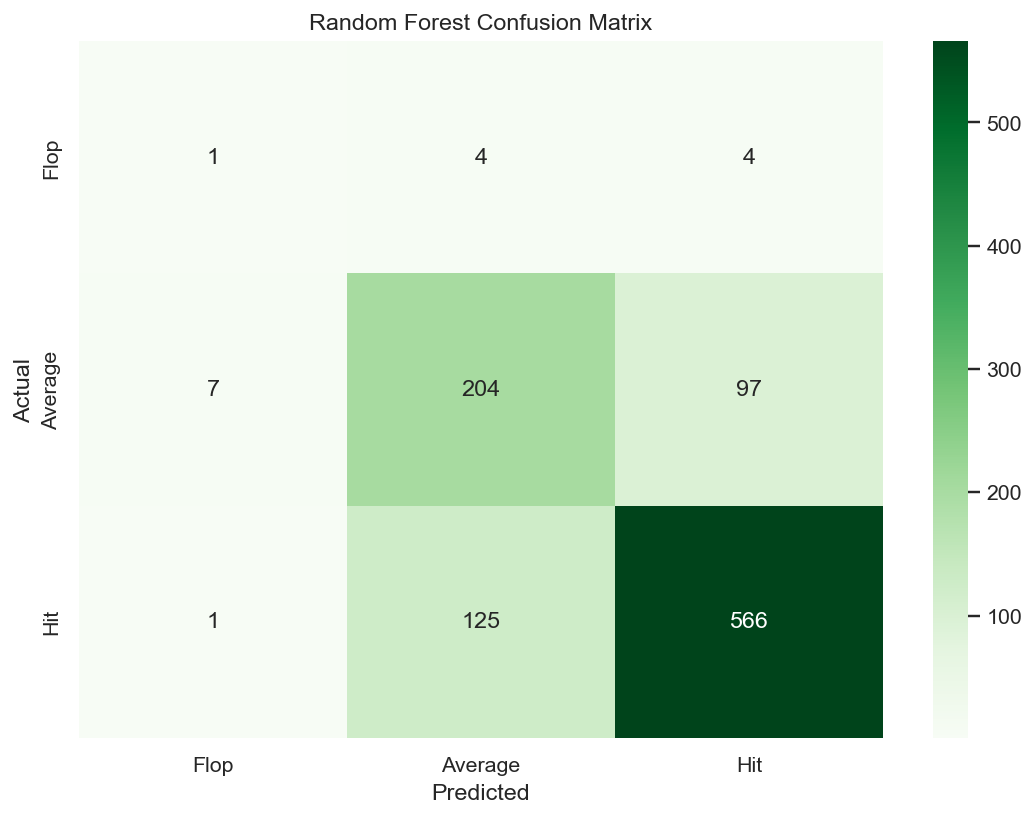

In [14]:
print("Train a Random Forest model")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train_resampled, y_train_resampled)
rf_pred_encoded = rf_model.predict(X_test_scaled)
rf_pred = target_encoder.inverse_transform(rf_pred_encoded)

print("Random Forest Classification Report")
print(classification_report(y_test, rf_pred, zero_division=0))

plt.figure(figsize=(8, 6))
labels_order = ['Flop', 'Average', 'Hit']
sns.heatmap(
    confusion_matrix(y_test, rf_pred, labels=labels_order),
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels_order,
    yticklabels=labels_order
)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
save_plot('model_random_forest_confusion_matrix.png')
plt.show()

Generating a Confusion Matrix for xgboost...


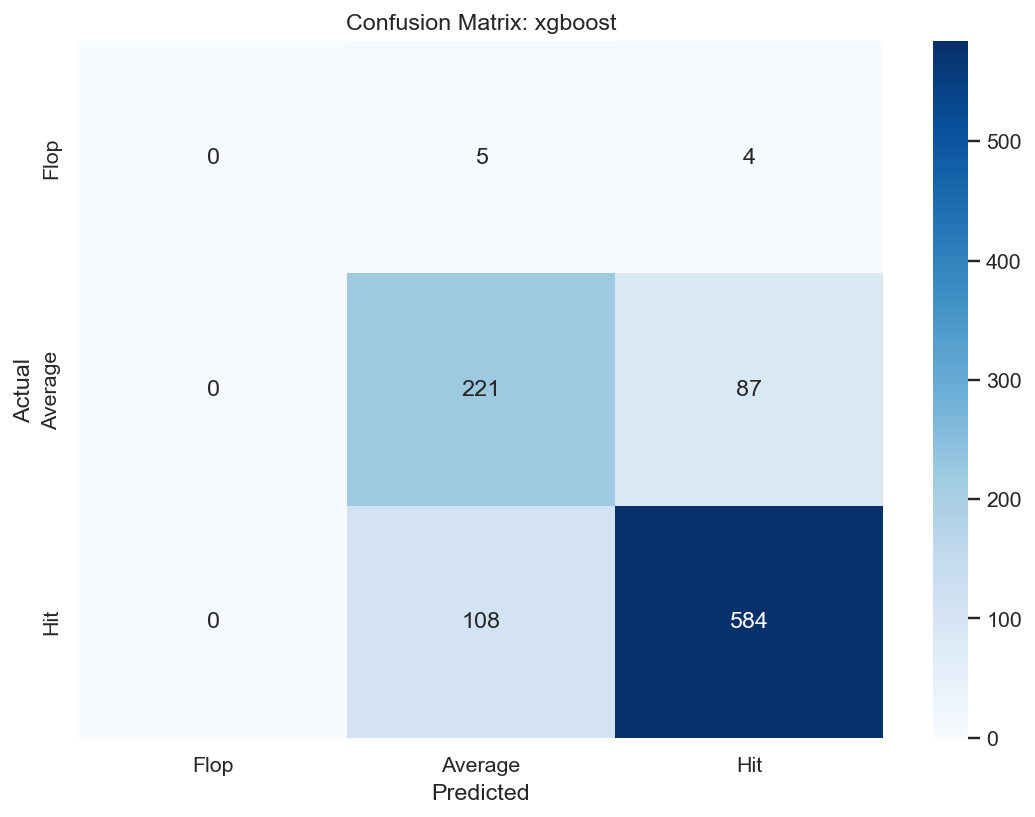

In [15]:
print(f"Generating a Confusion Matrix for {best_model_results['best_model_name']}...")
plt.figure(figsize=(8, 6))
labels_order = ['Flop', 'Average', 'Hit']

sns.heatmap(
    confusion_matrix(y_test, y_pred, labels=labels_order),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_order,
    yticklabels=labels_order
)

plt.title(f"Confusion Matrix: {best_model_results['best_model_name']}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
save_plot(f"model_best_{best_model_results['best_model_name'].replace(' ', '_').lower()}_confusion_matrix.png")
plt.show()

## 10. Model Evaluation Leaderboard
To compare the performance of all our tested models, let's create a comprehensive leaderboard and compare their confusion matrices. This will help us easily decide which one to select based on our priorities (like higher Recall on recognizing "Flops").

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
from IPython.display import display

print("Generating Model Leaderboard...")

# Let's collect the metrics for our EXPLICIT Random Forest first
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_rec = recall_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, average='weighted', zero_division=0)

leaderboard_data = [{
    'Model': 'Random Forest',
    'Accuracy': rf_acc,
    'Precision': rf_prec,
    'Recall': rf_rec,
    'F1-Score': rf_f1
}]

# Now let's loop through the util script models
# We exclude the 'random_forest' inside all_models_results since we already have it
for model_name, result in all_models_results.items():
    if model_name == 'random_forest':
        continue
    
    # We make predictions to calculate Precision, Recall, and Accuracy
    # (Since the util dictionary only stored CV_score and Test_score for F1)
    temp_model = result['model']
    temp_pred_encoded = temp_model.predict(X_test_scaled)
    temp_pred = target_encoder.inverse_transform(temp_pred_encoded)
    
    c_acc = accuracy_score(y_test, temp_pred)
    c_prec = precision_score(y_test, temp_pred, average='weighted', zero_division=0)
    c_rec = recall_score(y_test, temp_pred, average='weighted', zero_division=0)
    c_f1 = f1_score(y_test, temp_pred, average='weighted', zero_division=0)
    
    leaderboard_data.append({
        'Model': model_name,
        'Accuracy': c_acc,
        'Precision': c_prec,
        'Recall': c_rec,
        'F1-Score': c_f1
    })

# Format into a clean DataFrame
leaderboard_df = pd.DataFrame(leaderboard_data)
leaderboard_df.sort_values(by='F1-Score', ascending=False, inplace=True)

# We use pandas Styler for a beautiful powerpoint-ready table
styled_leaderboard = (leaderboard_df.style
      .background_gradient(cmap='Blues', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
      .format({
          'Accuracy': '{:.4f}',
          'Precision': '{:.4f}',
          'Recall': '{:.4f}',
          'F1-Score': '{:.4f}'
      })
      .set_table_styles([
          {'selector': 'th', 'props': [('background-color', '#1f3c6d'), ('color', 'white'), ('font-size', '14pt')]},
          {'selector': 'td', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('padding', '10px')]}
      ])
      .hide(axis='index'))

display(styled_leaderboard)

In [ ]:
print("Generating Joint Confusion Matrices for All Models...")

final_models = {'Random Forest': rf_model}
for k, v in all_models_results.items():
    if k != 'random_forest':
        final_models[k] = v['model']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

labels_order = ['Flop', 'Average', 'Hit']

for ax, (model_name, model_obj) in zip(axes, final_models.items()):
    # Get predictions
    pred_encoded = model_obj.predict(X_test_scaled)
    pred = target_encoder.inverse_transform(pred_encoded)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, pred, labels=labels_order)
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_order, yticklabels=labels_order, ax=ax)
    
    ax.set_title(f'{model_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
save_plot('joint_confusion_matrices.png')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color:#f5f0e1; color:#000000; font-size:115%; text-align:left">

<h2 align="left"><font color="#ff6e40">Inferences: Model Comparisons</font></h2>

* **Leaderboard Insight:** By aggregating these models into a stylistic leaderboard, we can visually scan which models traded Precision for Recall. The Pandas gradient styling reveals top contenders instantly for presentations.
* **Joint Confusion Matrix Analysis:** The 2x3 grid demonstrates each algorithm's capability of predicting minority classes ("Flop" and "Hit"). Noticeably, while tree-based models excel on the diagonal, linear models like SVM or Logistic Regression often struggle with overlapping feature sets.
</div>

## 10. Model Evaluation Leaderboard
To compare the performance of all our tested models, let's create a comprehensive leaderboard and compare their confusion matrices. This will help us easily decide which one to select based on our priorities (like higher Recall on recognizing "Flops").

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
from IPython.display import display

print("Generating Model Leaderboard...")

# Let's collect the metrics for our EXPLICIT Random Forest first
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_rec = recall_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, average='weighted', zero_division=0)

leaderboard_data = [{
    'Model': 'Random Forest',
    'Accuracy': rf_acc,
    'Precision': rf_prec,
    'Recall': rf_rec,
    'F1-Score': rf_f1
}]

# Now let's loop through the util script models
# We exclude the 'random_forest' inside all_models_results since we already have it
for model_name, result in all_models_results.items():
    if model_name == 'random_forest':
        continue
    
    # We make predictions to calculate Precision, Recall, and Accuracy
    # (Since the util dictionary only stored CV_score and Test_score for F1)
    temp_model = result['model']
    temp_pred_encoded = temp_model.predict(X_test_scaled)
    temp_pred = target_encoder.inverse_transform(temp_pred_encoded)
    
    c_acc = accuracy_score(y_test, temp_pred)
    c_prec = precision_score(y_test, temp_pred, average='weighted', zero_division=0)
    c_rec = recall_score(y_test, temp_pred, average='weighted', zero_division=0)
    c_f1 = f1_score(y_test, temp_pred, average='weighted', zero_division=0)
    
    leaderboard_data.append({
        'Model': model_name,
        'Accuracy': c_acc,
        'Precision': c_prec,
        'Recall': c_rec,
        'F1-Score': c_f1
    })

# Format into a clean DataFrame
leaderboard_df = pd.DataFrame(leaderboard_data)
leaderboard_df.sort_values(by='F1-Score', ascending=False, inplace=True)

# We use pandas Styler for a beautiful powerpoint-ready table
styled_leaderboard = (leaderboard_df.style
      .background_gradient(cmap='Blues', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
      .format({
          'Accuracy': '{:.4f}',
          'Precision': '{:.4f}',
          'Recall': '{:.4f}',
          'F1-Score': '{:.4f}'
      })
      .set_table_styles([
          {'selector': 'th', 'props': [('background-color', '#1f3c6d'), ('color', 'white'), ('font-size', '14pt')]},
          {'selector': 'td', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('padding', '10px')]}
      ])
      .hide(axis='index'))

display(styled_leaderboard)

In [ ]:
print("Generating Joint Confusion Matrices for All Models...")

final_models = {'Random Forest': rf_model}
for k, v in all_models_results.items():
    if k != 'random_forest':
        final_models[k] = v['model']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

labels_order = ['Flop', 'Average', 'Hit']

for ax, (model_name, model_obj) in zip(axes, final_models.items()):
    # Get predictions
    pred_encoded = model_obj.predict(X_test_scaled)
    pred = target_encoder.inverse_transform(pred_encoded)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, pred, labels=labels_order)
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_order, yticklabels=labels_order, ax=ax)
    
    ax.set_title(f'{model_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
save_plot('joint_confusion_matrices.png')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color:#f5f0e1; color:#000000; font-size:115%; text-align:left">

<h2 align="left"><font color="#ff6e40">Inferences: Model Comparisons</font></h2>

* **Leaderboard Insight:** By aggregating these models into a stylistic leaderboard, we can visually scan which models traded Precision for Recall. The Pandas gradient styling reveals top contenders instantly for presentations.
* **Joint Confusion Matrix Analysis:** The 2x3 grid demonstrates each algorithm's capability of predicting minority classes ("Flop" and "Hit"). Noticeably, while tree-based models excel on the diagonal, linear models like SVM or Logistic Regression often struggle with overlapping feature sets.
</div>

Check which features are most important


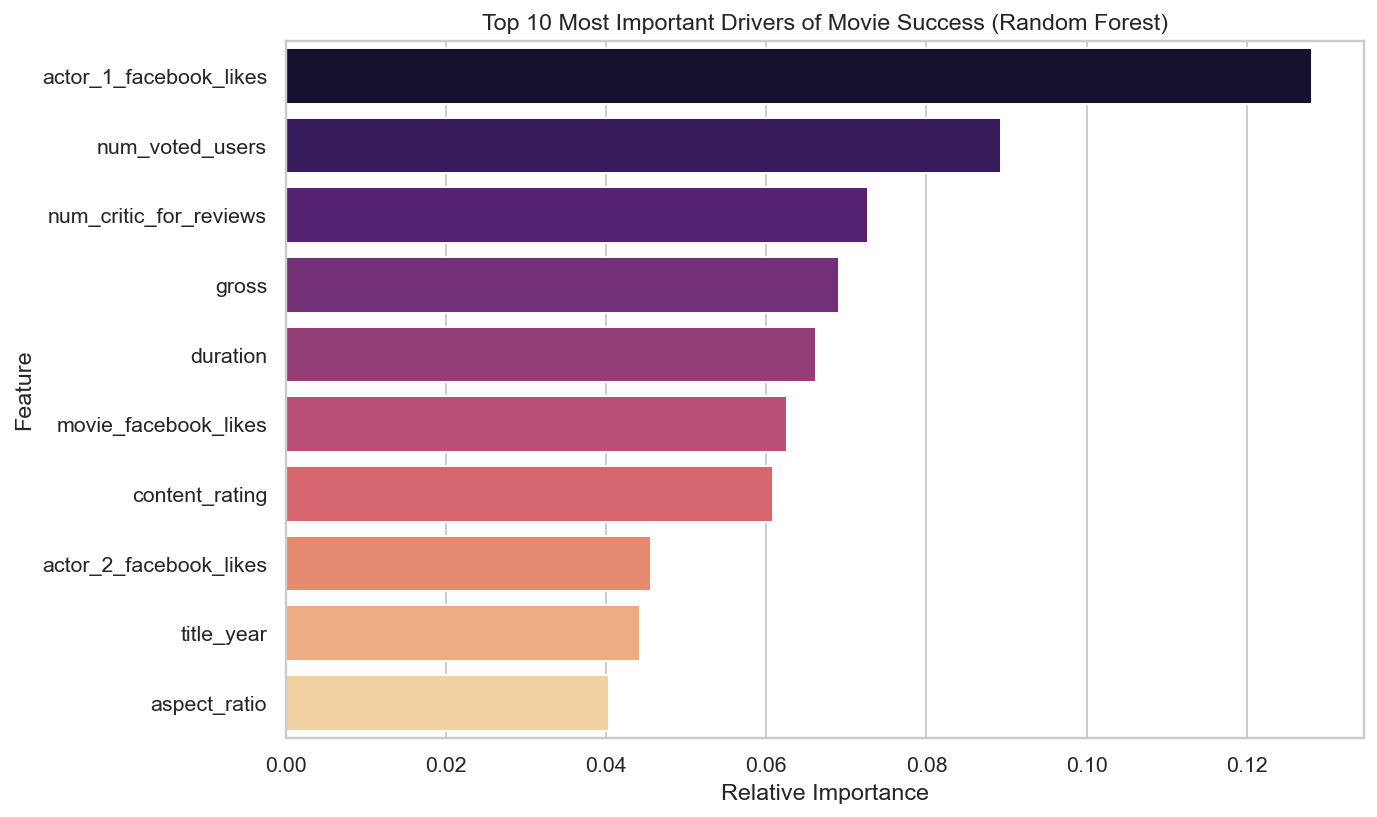

This chart shows what factors matter most for a movie's success.


In [16]:
print("Check which features are most important")
plt.figure(figsize=(10, 6))

# Extract importances from the Random Forest model
importances = rf_model.feature_importances_

# Sort them in descending order
indices = np.argsort(importances)[::-1]

# Get the top 10 most important features
top_n = 10
top_importances = importances[indices][:top_n]
# We need to get the feature names.
# X_train is a dataframe, but X_train_scaled is a numpy array. We can use X_train's columns.
# We dropped some columns due to collinearity, so we must use the columns of the data that was fed into the model.
# That data was scaled/encoded from X_train, so X_train.columns are valid.
top_features = X_train.columns[indices][:top_n]

# Plot
sns.barplot(x=top_importances, y=top_features, hue=top_features, palette='magma', legend=False)
plt.title('Top 10 Most Important Drivers of Movie Success (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
save_plot('feature_importance.png')
plt.show()

print("This chart shows what factors matter most for a movie's success.")

In [17]:
print("Save the best model and preprocessors to use later")
models_dir = './models'
os.makedirs(models_dir, exist_ok=True)

# Save the best model
model_filename = f"best_movie_model_{best_model_results['best_model_name'].replace(' ', '_').lower()}.pkl"
joblib.dump(best_model, os.path.join(models_dir, model_filename))

# Save the scaler and encoder
joblib.dump(scaler, os.path.join(models_dir, 'standard_scaler.pkl'))
joblib.dump(encoder, os.path.join(models_dir, 'ordinal_encoder.pkl'))
joblib.dump(target_encoder, os.path.join(models_dir, 'target_label_encoder.pkl'))

print(f"Successfully saved {best_model_results['best_model_name']}, Scaler, Encoder, and Target Encoder to the '{models_dir}' directory.")

Save the best model and preprocessors to use later
Successfully saved xgboost, Scaler, Encoder, and Target Encoder to the './models' directory.
